    T      tau   alpha(t,T)      v1(t,T)      v2(t,T)   ||v(t,T)||
-----------------------------------------------------------------
  0.5      0.0      0.00000      0.00000      0.00000      0.00000
  1.0      0.5      0.00020      0.00500      0.00906      0.01035
  2.0      1.5      0.00040      0.01500      0.02256      0.02709
  3.0      2.5      0.00048      0.02500      0.03161      0.04030


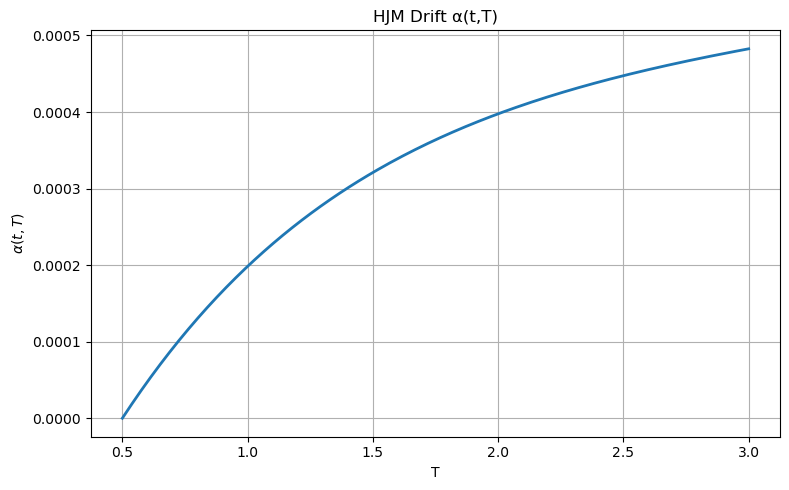

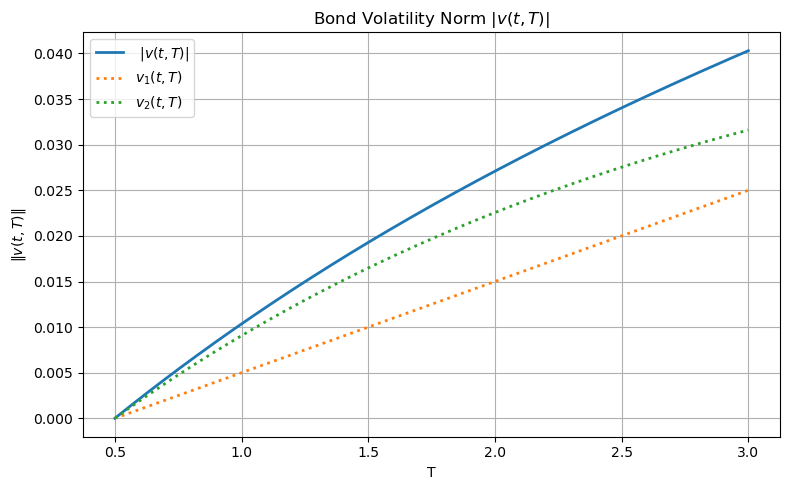

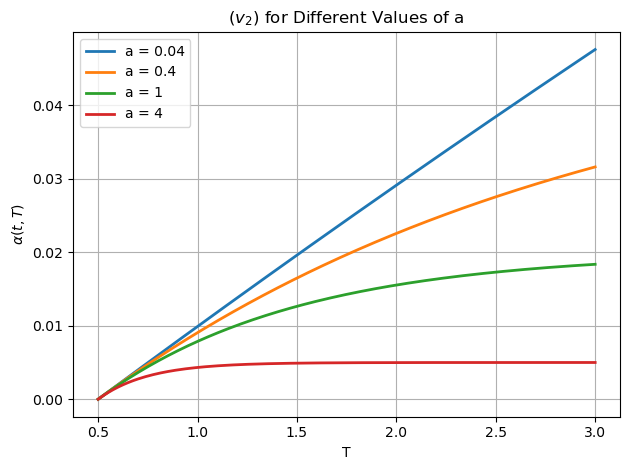

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
a = 0.4
sigma1 = 0.01
sigma2 = 0.02
t = 0.5

# Grid for T
T = np.linspace(0.5, 3.0, 200)
tau = T - t

# Forward-rate drift α(t,T)
alpha = sigma1**2 * tau + sigma2**2 * np.exp(-a*tau) * (1 - np.exp(-a*tau)) / a

# Bond vol components
v1 = sigma1 * tau
v2 = sigma2 * (1 - np.exp(-a*tau)) / a

# Scalar instantaneous volatility ||v||
v_norm = np.sqrt(v1**2 + v2**2)


# ---- Table values for T = {0.5, 1, 2, 3} ----
T_vals = np.array([0.5, 1.0, 2.0, 3.0])
tau_vals = T_vals - t
print(f"{'T':>5} {'tau':>8} {'alpha(t,T)':>12} {'v1(t,T)':>12} {'v2(t,T)':>12} {'||v(t,T)||':>12}")
print("-" * 65)
for Ti, tau_i in zip(T_vals, tau_vals):
    alpha_i = sigma1**2 * tau_i + sigma2**2 * np.exp(-a * tau_i) * (1 - np.exp(-a * tau_i)) / a
    v1_i = sigma1 * tau_i
    v2_i = sigma2 * (1 - np.exp(-a * tau_i)) / a
    vnorm_i = np.sqrt(v1_i**2 + v2_i**2)
    print(f"{Ti:5.1f} {tau_i:8.1f} {alpha_i:12.5f} {v1_i:12.5f} {v2_i:12.5f} {vnorm_i:12.5f}")



# ---- Plot α(t,T) ----
plt.figure(figsize=(8,5))
plt.plot(T, alpha, linewidth=2)
plt.xlabel("T")
plt.ylabel(r"$\alpha(t,T)$")
plt.title("HJM Drift α(t,T)")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- Plot ||v(t,T)|| ----
plt.figure(figsize=(8,5))
plt.plot(T, v_norm, label=r" $|v(t,T)|$", linewidth=2)
plt.plot(T, v1, label=r"$v_1(t,T)$", linewidth=2, linestyle=':')
plt.plot(T, v2, label=r"$v_2(t,T)$", linewidth=2, linestyle=':')
plt.xlabel("T")
plt.ylabel(r"$\|v(t,T)\|$")
plt.title("Bond Volatility Norm $|v(t,T)|$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#---- Plot v2 for different a ----
a_values = [0.04, 0.4, 1, 4]
for a in a_values:
    v2 = sigma2 * (1 - np.exp(-a*tau)) / a
    plt.plot(T, v2, label=f"a = {a}", linewidth=2)

plt.xlabel("T")
plt.ylabel(r"$\alpha(t,T)$")
plt.title("$(v_2)$ for Different Values of a")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()